In [6]:
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append('../../datasets')
from load_data import get_datasets

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
ds_train, ds_val, ds_test, class_weights = get_datasets("daliac", "../../datasets/daliac/")

labels = {1: 'sitting', 2: 'lying', 3: 'standing', 4: 'washing_dishes', 5: 'vacuuming', 
          6: 'sweeping',  7: 'walking', 8: 'ascending_stairs', 9: 'descending_stairs', 10: 'treadmill_running', 
          11: 'bicycling_on_ergometer_50_W', 12: 'bicycling_on_ergometer_100_W', 13: 'rope_jumping'}


In [71]:
for x, y in ds_train:
    print(x.shape, y.shape)
    print(np.unique(y))
    break

(2048, 1) ()
[1]


: 

In [66]:
def get_class_distribution(ds):
    labels = [int(label) for _, label in ds]
    return np.bincount(labels, minlength=14)[1:]

In [67]:
train_distribution = get_class_distribution(ds_train)
val_distribution = get_class_distribution(ds_val)
test_distribution = get_class_distribution(ds_test)

In [68]:
def plot_distribution(distribution, title):
    fig, ax = plt.subplots()
    ax.pie(distribution, labels=[labels[i] for i in range(1, len(labels)+1)], autopct='%1.1f%%')
    ax.axis('equal')
    plt.title(title)
    plt.show()

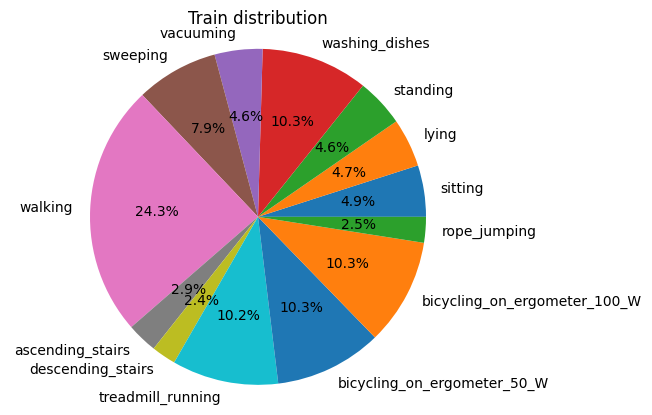

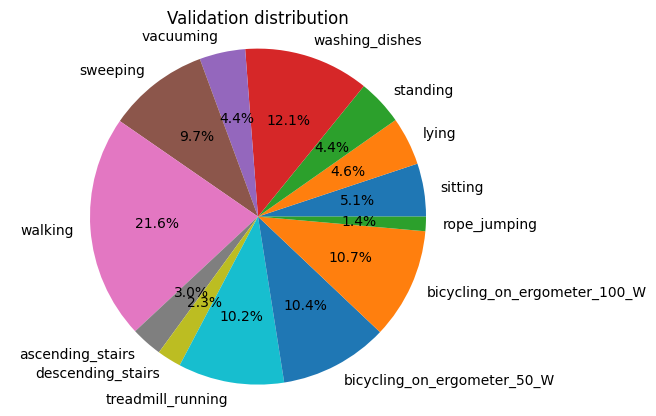

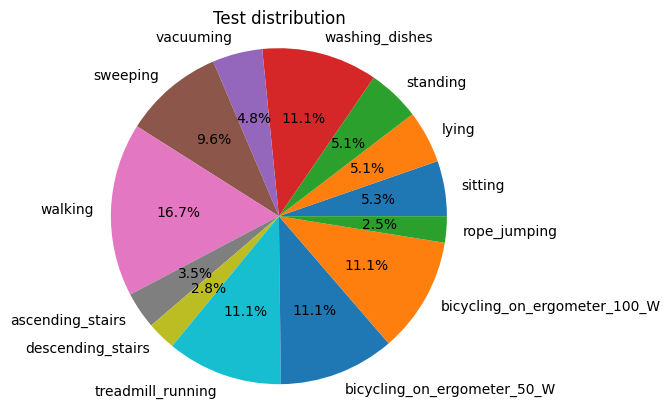

In [69]:
plot_distribution(train_distribution, 'Train distribution')
plot_distribution(val_distribution, 'Validation distribution')
plot_distribution(test_distribution, 'Test distribution')

In [70]:
# print raw numbers of samples presented nicely in a table in markdown
print('| Class | Train | Validation | Test |')
print('|-------|-------|------------|------|')
for i in range(13):
    print(f'| {labels[i+1]} | {train_distribution[i]} | {val_distribution[i]} | {test_distribution[i]} |')
    


| Class | Train | Validation | Test |
|-------|-------|------------|------|
| sitting | 160 | 22 | 21 |
| lying | 151 | 20 | 20 |
| standing | 150 | 19 | 20 |
| washing_dishes | 333 | 52 | 44 |
| vacuuming | 149 | 19 | 19 |
| sweeping | 256 | 42 | 38 |
| walking | 786 | 93 | 66 |
| ascending_stairs | 95 | 13 | 14 |
| descending_stairs | 76 | 10 | 11 |
| treadmill_running | 331 | 44 | 44 |
| bicycling_on_ergometer_50_W | 334 | 45 | 44 |
| bicycling_on_ergometer_100_W | 332 | 46 | 44 |
| rope_jumping | 80 | 6 | 10 |
